Label Encoding Process and Data Visualization (**Golinia**)

In [ ]:
import pandas as pd

# Make sure the filename matches exactly what is in your sidebar
df = pd.read_csv('/_student_food_expenses 2.0.csv')

# This shows you the first 5 rows to confirm it loaded correctly
df.head()

,Gender,Age,Current residence,Number of Meals per Day,Average Price of Meal (RM),Main Eating Location,Do You Cook Your Own Meals,Number of Snacks or Drinks Consumed in a Day,Estimated Daily Food Expenses (RM),Monthly Allowance,Type of Day,Do You Eat Outside More Than Once Per Day
0,0,22,Hostel,2,14,Outside Restaurant,0,0.5,16,200,1,0
1,0,19,Hostel,2,8,Outside Restaurant,0,0.5,16,200,1,1
2,1,22,Hostel,2,18,Outside Restaurant,0,2.5,16,400,1,1
3,0,24,Rented House,4,18,Self-Cooking,1,2.5,16,400,1,0
4,0,22,Rented House,1,14,Outside Restaurant,1,0.5,16,200,1,1


In [ ]:
# Strip hidden spaces from text columns
df['Current residence'] = df['Current residence'].str.strip()
df['Main Eating Location'] = df['Main Eating Location'].str.strip()

In [ ]:
# Make everything Title Case
df['Current residence'] = df['Current residence'].str.title()
df['Main Eating Location'] = df['Main Eating Location'].str.title()

In [ ]:
# Fill any last-minute empty category cells with 'Unknown'
df['Current residence'] = df['Current residence'].fillna('Unknown')
df['Main Eating Location'] = df['Main Eating Location'].fillna('Unknown')

Residence Mapping: {'Hostel': np.int64(0), 'Living With Family': np.int64(1), 'Rented House': np.int64(2)}
Location Mapping: {'Campus Cafeteria': np.int64(0), 'Outside Restaurant': np.int64(1), 'Self-Cooking': np.int64(2)}


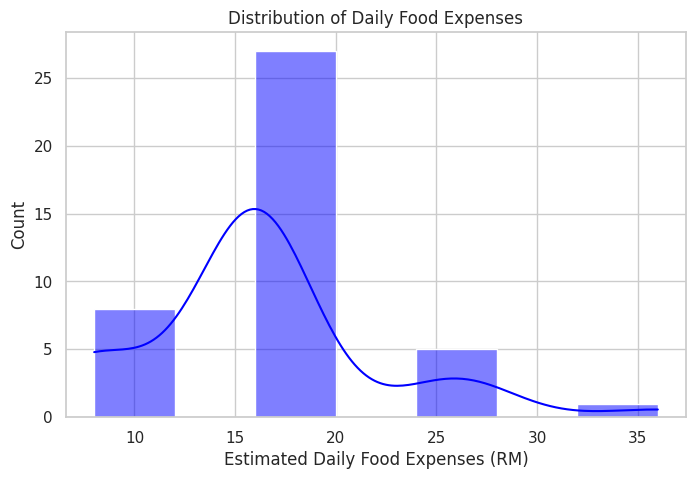

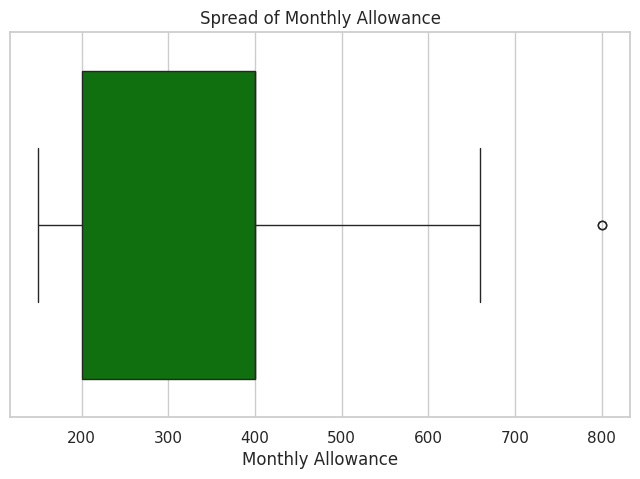

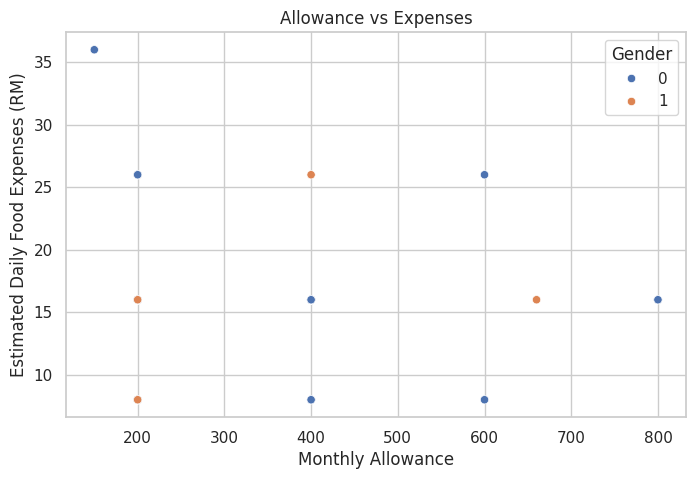

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Load the data
df = pd.read_csv('/_student_food_expenses 2.0.csv')

# --- PRE-ENCODING CLEANING (Ensuring Label Encoding works) ---
df['Current residence'] = df['Current residence'].str.strip().str.title()
df['Main Eating Location'] = df['Main Eating Location'].str.strip().str.title()

# --- TASK 1: LABEL ENCODING ---
le = LabelEncoder()

# Create the encoded columns
df['Current_residence_num'] = le.fit_transform(df['Current residence'])
# Print mapping for report
res_map = dict(zip(le.classes_, le.transform(le.classes_)))

df['Main_Eating_Location_num'] = le.fit_transform(df['Main Eating Location'])
# Print mapping for report
loc_map = dict(zip(le.classes_, le.transform(le.classes_)))

print("Residence Mapping:", res_map)
print("Location Mapping:", loc_map)

# --- TASK 2: VISUALIZATION ---
sns.set(style="whitegrid")

# Histogram: Daily Expenses
plt.figure(figsize=(8, 5))
sns.histplot(df['Estimated Daily Food Expenses (RM)'], kde=True, color='blue')
plt.title('Distribution of Daily Food Expenses')
plt.savefig('expenses_hist.png')
plt.show()

# Box Plot: Monthly Allowance
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Monthly Allowance'], color='green')
plt.title('Spread of Monthly Allowance')
plt.savefig('allowance_box.png')
plt.show()

# Scatter Plot: Relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Monthly Allowance', y='Estimated Daily Food Expenses (RM)', hue='Gender')
plt.title('Allowance vs Expenses')
plt.savefig('rel_scatter.png')
plt.show()

# 4. Save and Download for Member 3
df.to_csv('final_encoded_data.csv', index=False)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# 1. Load the file
df = pd.read_csv('/_student_food_expenses 2.0.csv')

# 2. Initialize Encoder
le = LabelEncoder()

# 3. List the columns that are still "Words"
categorical_columns = ['Current residence', 'Main Eating Location']

# 4. OVERWRITE the text with numbers
for col in categorical_columns:
    # This line is the secret: it replaces 'Hostel' with 0, 1, or 2
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"✅ Successfully converted {col} into numbers.")

# 5. Check the result in the console first
print("\nPreview of the new data (should be all numbers):")
print(df.head())

# 6. Save and Download
# We save the 'df' because it now contains the numbers
df.to_csv('fully_encoded_data.csv', index=False)
files.download('fully_encoded_data.csv')

✅ Successfully converted Current residence into numbers.
✅ Successfully converted Main Eating Location into numbers.

Preview of the new data (should be all numbers):
   Gender  Age  Current residence  Number of Meals per Day  \
0       0   22                  0                        2   
1       0   19                  0                        2   
2       1   22                  0                        2   
3       0   24                  2                        4   
4       0   22                  2                        1   

   Average Price of Meal (RM)  Main Eating Location  \
0                          14                     1   
1                           8                     1   
2                          18                     1   
3                          18                     2   
4                          14                     1   

   Do You Cook Your Own Meals  Number of Snacks or Drinks Consumed in a Day  \
0                           0                     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Linear Regression Model (**Syahira**)

Model Coefficients: [ 3.48351206  0.03232841  3.09870665  0.18243769  1.11283464 -0.3464987
 -0.01230166  3.96448807  1.55047608]
Model Intercept: 6.173935256025084
Mean Squared Error: 22.58766456433412
R-squared: 0.24769702725696396


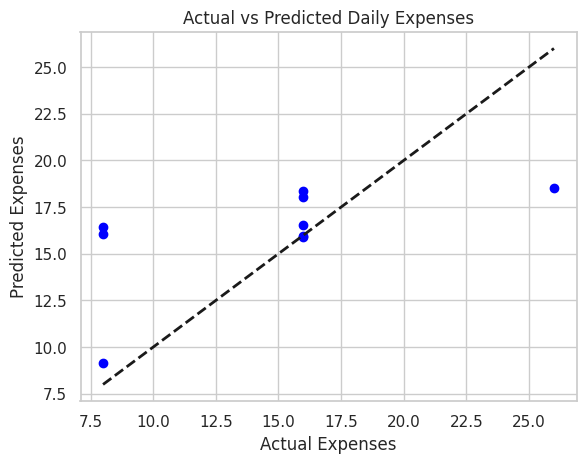

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the data
df = pd.read_csv('/content/_student_food_expenses 2.0.csv')

# 2. Prepare the data
# Y = Target (Expenses)
Y = df['Estimated Daily Food Expenses (RM)']

# X = Features (Everything else numeric)
# Dropping the target and non-numeric columns
X = df.drop(columns=['Estimated Daily Food Expenses (RM)', 'Current residence', 'Main Eating Location'])

# 3. Split the dataset (80% Train, 20% Test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Build and fit the model
model = LinearRegression()
model.fit(X_train, Y_train)

# 5. Make Predictions
Y_pred = model.predict(X_test)

# 6. Evaluate
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("Mean Squared Error:", mean_squared_error(Y_test, Y_pred))
print("R-squared:", r2_score(Y_test, Y_pred))

# 7. Plotting Actual vs Predicted
plt.scatter(Y_test, Y_pred, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Expenses')
plt.ylabel('Predicted Expenses')
plt.title('Actual vs Predicted Daily Expenses')
plt.show()

Feature Importance

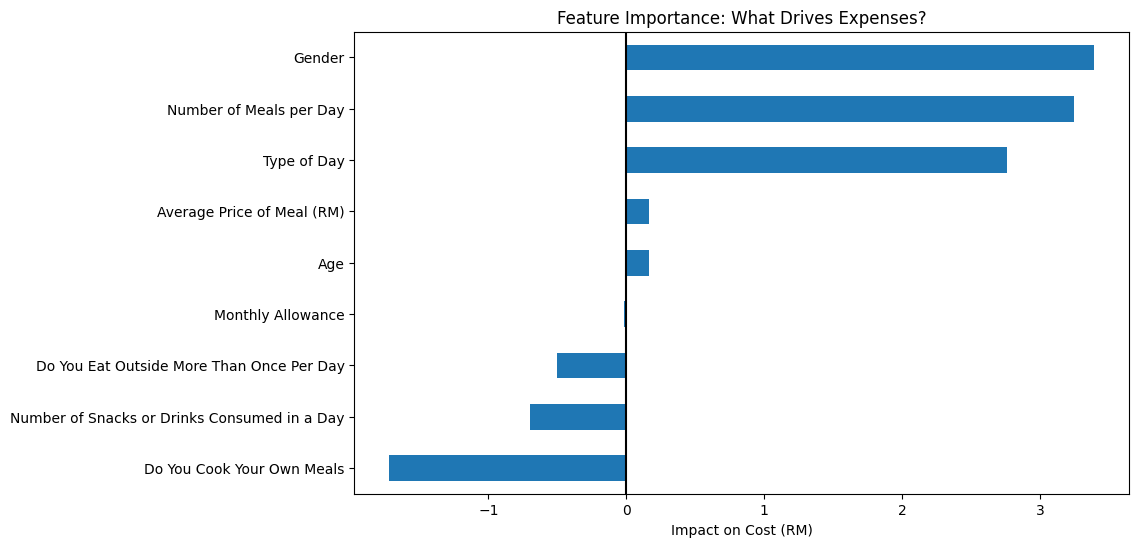

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# (Assuming model is already trained)
coefs = pd.Series(model.coef_, index=X.columns)

# Plotting
plt.figure(figsize=(10, 6))
coefs.sort_values().plot(kind='barh')
plt.title("Feature Importance: What Drives Expenses?")
plt.xlabel("Impact on Cost (RM)")
plt.axvline(x=0, color='black') # Adds the zero line
plt.show()

Data Cleaning

In [ ]:
import pandas as pd

# Load dataset
file_path = "_student_food_expenses 2.0.csv"
df = pd.read_csv(file_path)

# -------------------------------
# 1. Clean column names
# -------------------------------
df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

# -------------------------------
# 2. Check duplicates (DO NOT REMOVE)
# -------------------------------
print("Duplicate rows:", df.duplicated().sum())

# -------------------------------
# 3. Handle missing values
# -------------------------------
print(df.isnull().sum())

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -------------------------------
# 4. Clean Age safely (no row removal)
# -------------------------------
df['Age'] = (
    df['Age']
    .astype(str)
    .str.extract(r'(\d+)')  # extract first number
    .astype(float)
)

df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# -------------------------------
# 5. Fix Monthly Allowance
# -------------------------------
df['Monthly_Allowance'] = pd.to_numeric(
    df['Monthly_Allowance'], errors='coerce'
).fillna(df['Monthly_Allowance'].median())

# -------------------------------
# 6. Standardize categorical text
# -------------------------------
df['Current_residence'] = df['Current_residence'].str.strip().str.title()
df['Main_Eating_Location'] = df['Main_Eating_Location'].str.strip().str.title()

# -------------------------------
# 7. Rename columns
# -------------------------------
df = df.rename(columns={
    'Average_Price_of_Meal_RM': 'Avg_Meal_Price',
    'Estimated_Daily_Food_Expenses_RM': 'Daily_Food_Expenses',
    'Number_of_Snacks_or_Drinks_Consumed_in_a_Day': 'Snacks_Per_Day'
})

# -------------------------------
# 8. Save cleaned dataset
# -------------------------------
df.to_csv("cleaned_student_food_expenses.csv", index=False)

print(" Data cleaning complete without removing any records.")
print("Final row count:", df.shape[0])

Duplicate rows: 1
Gender                                          0
Age                                             0
Current_residence                               0
Number_of_Meals_per_Day                         0
Average_Price_of_Meal_RM                        0
Main_Eating_Location                            0
Do_You_Cook_Your_Own_Meals                      0
Number_of_Snacks_or_Drinks_Consumed_in_a_Day    0
Estimated_Daily_Food_Expenses_RM                0
Monthly_Allowance                               0
Type_of_Day                                     0
Do_You_Eat_Outside_More_Than_Once_Per_Day       0
dtype: int64
 Data cleaning complete without removing any records.
Final row count: 41


Model Training

In [ ]:
# 1. Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 2. Load the Data
df = pd.read_csv('/content/_student_food_expenses 2.0.csv')

# 3. Define X (Inputs) and Y (Target)
# We drop the target column and text columns to get our features
X = df.drop(columns=['Estimated Daily Food Expenses (RM)', 'Current residence', 'Main Eating Location'])
Y = df['Estimated Daily Food Expenses (RM)']

# 4. Split the Data (THIS IS THE MISSING PART)
# This creates the 'X_train' variable your error was asking for
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# --- NOW YOUR SLIDE CODE WILL WORK ---

# 5. Initialize and Train
model = LinearRegression()
model.fit(X_train, Y_train)  # Now X_train is defined!

# 6. Predict and Evaluate
predictions = model.predict(X_test)
print("Model trained successfully!")
print(f"Model Accuracy: {model.score(X_test, Y_test)}")

Model trained successfully!
Model Accuracy: 0.24769702725696396


Model Accuracy

In [ ]:
# 1. Import Library
from sklearn.linear_model import LinearRegression

# 2. Initialize and Train
model = LinearRegression()
model.fit(X_train, Y_train)  # Training on 80% of data

# 3. Predict and Evaluate
predictions = model.predict(X_test)
print(f"Model Accuracy: {model.score(X_test, Y_test)}")

Model Accuracy: 0.24769702725696396


In [ ]:
intercept = model.intercept_
coefficients = model.coef_
feature_names = X.columns

# Print the Intercept
print(f"Base Cost (Intercept): RM {intercept:.2f}")

# Print the Equation clearly
print("\nThe Model Equation:")
print(f"Cost = {intercept:.2f}", end=" ")

for feature, coef in zip(feature_names, coefficients):

    if abs(coef) > 1.0:
        print(f"+ ({coef:.2f} * {feature})", end=" ")

Base Cost (Intercept): RM 6.17

The Model Equation:
Cost = 6.17 + (3.48 * Gender) + (3.10 * Number of Meals per Day) + (1.11 * Do You Cook Your Own Meals) + (3.96 * Type of Day) + (1.55 * Do You Eat Outside More Than Once Per Day) 

Model Evaluation

Model Evaluation Metrics:
-------------------------
R-Squared (Accuracy): 0.247697
RMSE (Root Mean Sq Error): 4.752648
MAE (Mean Absolute Error): 3.363111


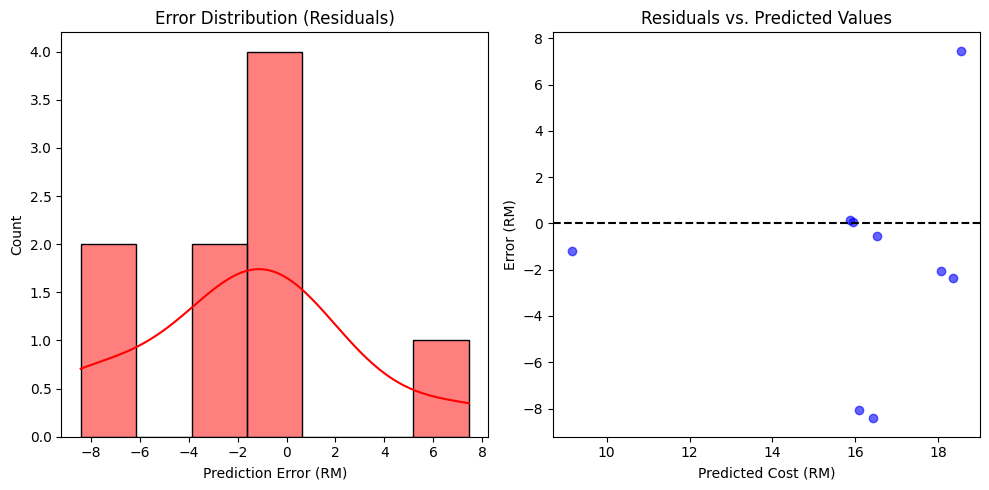


Error Analysis Interpretation:
1. If the R² is close to 1, the model explains the variance well.
2. In the 'Residuals vs Predicted' plot, points should be randomly scattered around the line 0.
3. If there is a pattern (like a curve), the linear model might be too simple.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Add missing imports for the model setup
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ==========================================
# 4. EVALUATE THE MODEL (WITH PRE-REQUISITES)
# ==========================================

# --- Start of added code to ensure Y_test and Y_pred are defined ---
# 1. Load the data (if not already loaded, or to ensure fresh data)
df = pd.read_csv('/content/_student_food_expenses 2.0.csv')

# 2. Prepare the data
Y = df['Estimated Daily Food Expenses (RM)']
X = df.drop(columns=['Estimated Daily Food Expenses (RM)', 'Current residence', 'Main Eating Location'])

# 3. Split the dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Build and fit the model
model = LinearRegression()
model.fit(X_train, Y_train)

# 5. Make Predictions
Y_pred = model.predict(X_test)
# --- End of added code ---


# A. Calculate Performance Metrics dynamically
# ------------------------------------------
# Calculate metrics using the newly defined Y_test and Y_pred
r2 = r2_score(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = mean_absolute_error(Y_test, Y_pred)

print("Model Evaluation Metrics:")
print(f"-------------------------")
print(f"R-Squared (Accuracy): {r2:.6f}")
print(f"RMSE (Root Mean Sq Error): {rmse:.6f}")
print(f"MAE (Mean Absolute Error): {mae:.6f}")


# B. Error Analysis (Residual Plot)
# ------------------------------------------
residuals = Y_test - Y_pred

plt.figure(figsize=(10, 5))

# Plot 1: Residuals Distribution (Is the error random?)
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='red')
plt.title("Error Distribution (Residuals)")
plt.xlabel("Prediction Error (RM)")

# Plot 2: Residuals vs. Predicted (Homoscedasticity Check)
plt.subplot(1, 2, 2)
plt.scatter(Y_pred, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Cost (RM)")
plt.ylabel("Error (RM)")

plt.tight_layout()
plt.show()

# Interpretation printout
print("\nError Analysis Interpretation:")
print("1. If the R² is close to 1, the model explains the variance well.")
print("2. In the 'Residuals vs Predicted' plot, points should be randomly scattered around the line 0.")
print("3. If there is a pattern (like a curve), the linear model might be too simple.")